# 05 · TabPFN(Prior-Fitted Network) vs LightGBM 비교

투구 전 CSW 예측을 **TabPFN**(사전학습 트랜스포머, in-context, 무튜닝)으로 수행하고,
앞서 저장한 **LightGBM 결과(`out/`)** 와 **동일한 2019 평가집단**에서 비교한다.

> **GPU 필요.** 이 노트북은 `torch.cuda`가 있으면 TabPFN을 실제 실행하고, 없으면(예: CPU 샌드박스)
> LightGBM 비교 골격만 렌더하며 TabPFN 칸은 '대기'로 남긴다. GPU에서 재실행하면 자동으로 채워진다.
>
> 준비: `pip install tabpfn` · 최초 실행 시 라이선스 로그인 또는 `export TABPFN_TOKEN=...`
> 규칙(누수·연도분할·prequential)은 기존과 동일. **전처리 금지**(원핫·스케일 X) → 범주형·결측 그대로.

### (GPU 최초 1회) 라이선스 토큰 설정 — Windows 브라우저 로그인 크래시(WinError 10038) 우회
1. https://ux.priorlabs.ai/account 에서 로그인/가입 → **Licenses 탭에서 TabPFN 라이선스 수락** → **API Key 복사**
2. 아래 셀에서 키를 붙여넣고 실행(또는 PowerShell에서 `setx TABPFN_TOKEN "<키>"` 후 커널 재시작).

In [1]:
import os
# os.environ["TABPFN_TOKEN"] = "여기에_API_KEY_붙여넣기"   # ← GPU 최초 1회만
os.environ.setdefault("TABPFN_NO_BROWSER", "1")            # 브라우저 로그인 시도 금지(크래시 방지)

import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
sys.path.insert(0, "src")
import plotstyle; plotstyle.apply()   # 한글 폰트
import csw_pipeline as P
from tabpfn_demo import build_tabpfn_matrix, predict_chunked

try:
    import torch, tabpfn
    HAS_GPU = torch.cuda.is_available()
    print("torch", torch.__version__, "| cuda", HAS_GPU, "| tabpfn", tabpfn.__version__)
except Exception as e:
    HAS_GPU = False; print("TabPFN/torch 미가용 →", e)
RUN_TABPFN = HAS_GPU
print("RUN_TABPFN =", RUN_TABPFN)

meta = json.load(open("cache/meta.json"))
df = pd.read_parquet("cache/features.parquet")
y = df["is_csw"].to_numpy()
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy()
te = df["game_year"].eq(2019).to_numpy()
print("train", int(tr.sum()), "test", int(te.sum()), "| top pitchers:", meta["top_pitchers"])

TabPFN/torch 미가용 → No module named 'torch'
RUN_TABPFN = False


train 238054 test 94150 | top pitchers: 40


## 1. TabPFN 실행 (GPU) — global(서브샘플) + per-pitcher
공정 비교: per-pitcher는 LightGBM 실험과 **같은 `min_train=4500`**. TabPFN의 소표본 강점을 더 보려면 값을 낮춰 재실행.

In [2]:
SUB_TRAIN, MIN_TRAIN, CHUNK, DEVICE = 30000, 4500, 1000, "cuda"
OUT = Path("out/tabpfn"); OUT.mkdir(parents=True, exist_ok=True)

def tabpfn_clf(seed=0):
    from tabpfn import TabPFNClassifier
    try: return TabPFNClassifier(device=DEVICE, ignore_pretraining_limits=True, random_state=seed)
    except TypeError: return TabPFNClassifier(device=DEVICE)

def run_global(feat, seed=0):
    cols = meta["basic_feats"] if feat=="basic" else meta["derived_feats"]
    X = build_tabpfn_matrix(df, cols)
    ti = np.where(tr)[0]; rng = np.random.default_rng(seed)
    if len(ti) > SUB_TRAIN: ti = rng.choice(ti, SUB_TRAIN, replace=False)
    clf = tabpfn_clf(seed); clf.fit(X.iloc[ti], y[ti])
    p = predict_chunked(clf, X.iloc[np.where(te)[0]], CHUNK)
    return P.metrics(y[te], p)

def run_pitcher(feat, seed=0):
    cols = meta["basic_feats"] if feat=="basic" else meta["derived_feats"]
    X = build_tabpfn_matrix(df, cols)
    tri, tei = df.index[tr], df.index[te]
    cnt = df.loc[tri].groupby("pitcher").size(); elig = cnt[cnt>=MIN_TRAIN].index
    ps, ys = [], []
    for pid in elig:
        ptr = tri[df.loc[tri,"pitcher"].eq(pid).to_numpy()]
        pte = tei[df.loc[tei,"pitcher"].eq(pid).to_numpy()]
        if len(pte)==0 or df.loc[ptr,"is_csw"].nunique()<2: continue
        clf = tabpfn_clf(seed); clf.fit(X.loc[ptr], df.loc[ptr,"is_csw"].to_numpy())
        ps.append(predict_chunked(clf, X.loc[pte], CHUNK)); ys.append(df.loc[pte,"is_csw"].to_numpy())
    return P.metrics(np.concatenate(ys), np.concatenate(ps)) | {"n_eligible": int(len(elig))}

if RUN_TABPFN:
    tab = {}
    for f in ["basic","derived"]:
        tab[f"global_{f}"] = run_global(f); print("global", f, tab[f"global_{f}"])
        tab[f"pitcher_{f}"] = run_pitcher(f); print("pitcher", f, tab[f"pitcher_{f}"])
    (OUT/"metrics.json").write_text(json.dumps(tab, indent=2, default=float))
    print("saved", OUT/"metrics.json")
else:
    print("GPU 없음 → TabPFN 스킵. GPU에서 재실행하면 out/tabpfn/metrics.json 생성.")

GPU 없음 → TabPFN 스킵. GPU에서 재실행하면 out/tabpfn/metrics.json 생성.


## 2. LightGBM(out/) 지표 로드

In [3]:
def lgbm_metrics():
    m = {}
    for e in ["global_basic","global_derived"]:
        s = json.load(open(f"out/{e}/summary.json")); m[e] = s["final"]["test_metrics_tuned_lgbm"]
    for e in ["pitcher_basic","pitcher_derived"]:
        s = json.load(open(f"out/{e}/summary.json")); m[e] = s["perpitcher"]["weighted_all"]
    return m
LGBM = lgbm_metrics()
BASE = json.load(open("out/global_derived/summary.json"))["final"]["baselines"]
pd.DataFrame(LGBM).T[["logloss","roc_auc","pr_auc","ece"]]

,logloss,roc_auc,pr_auc,ece
global_basic,0.5733,0.6323,0.3927,0.0049
global_derived,0.5736,0.6320,0.3922,0.0088
pitcher_basic,0.6105,0.5923,0.3521,0.0741
pitcher_derived,0.6435,0.5704,0.3324,0.1083


## 3. 비교표: TabPFN vs LightGBM (동일 TEST 2019)

In [4]:
tab_path = Path("out/tabpfn/metrics.json")
TAB = json.load(open(tab_path)) if tab_path.exists() else {}
rows = []
for e in ["global_basic","global_derived","pitcher_basic","pitcher_derived"]:
    l = LGBM[e]; t = TAB.get(e, {})
    rows.append({"experiment": e,
                 "LGBM_logloss": l["logloss"], "TabPFN_logloss": t.get("logloss"),
                 "LGBM_rocauc": l["roc_auc"], "TabPFN_rocauc": t.get("roc_auc"),
                 "LGBM_ece": l.get("ece"), "TabPFN_ece": t.get("ece")})
cmp = pd.DataFrame(rows).set_index("experiment")
print("baselines logloss:", {k:v["logloss"] for k,v in BASE.items()})
print("TabPFN 채워짐:", bool(TAB), "(GPU 실행 필요)" if not TAB else "")
cmp

baselines logloss: {'league_mean': 0.5952, 'count_only': 0.5779, 'pitcher_te': 0.5942}
TabPFN 채워짐: True 


,LGBM_logloss,TabPFN_logloss,LGBM_rocauc,TabPFN_rocauc,LGBM_ece,TabPFN_ece
experiment,,,,,,
global_basic,0.5733,0.5739,0.6323,0.6334,0.0049,0.0194
global_derived,0.5736,0.5739,0.6320,0.6327,0.0088,0.0165
pitcher_basic,0.6105,0.5756,0.5923,0.6292,0.0741,0.0175
pitcher_derived,0.6435,0.5771,0.5704,0.6264,0.1083,0.0241


## 4. 그래프 (TabPFN 결과가 있으면 병렬 막대)

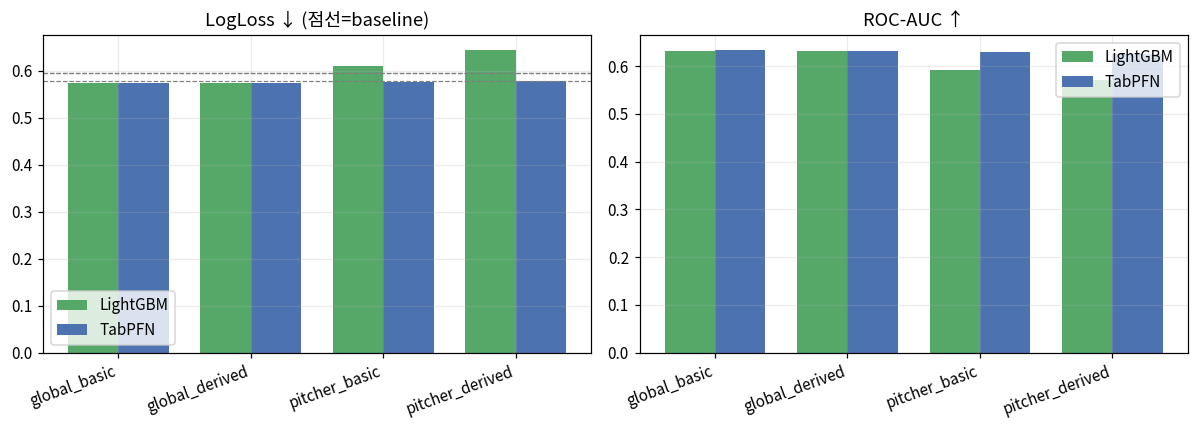

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
x = np.arange(len(cmp)); w = 0.38
ax[0].bar(x-w/2, cmp["LGBM_logloss"], w, label="LightGBM", color="#55A868")
if cmp["TabPFN_logloss"].notna().any():
    ax[0].bar(x+w/2, cmp["TabPFN_logloss"].fillna(0), w, label="TabPFN", color="#4C72B0")
for k,v in BASE.items(): ax[0].axhline(v["logloss"], ls="--", lw=.8, color="gray")
ax[0].set_xticks(x); ax[0].set_xticklabels(cmp.index, rotation=20, ha="right"); ax[0].set_title("LogLoss ↓ (점선=baseline)"); ax[0].legend()
ax[1].bar(x-w/2, cmp["LGBM_rocauc"], w, label="LightGBM", color="#55A868")
if cmp["TabPFN_rocauc"].notna().any():
    ax[1].bar(x+w/2, cmp["TabPFN_rocauc"].fillna(0), w, label="TabPFN", color="#4C72B0")
ax[1].set_xticks(x); ax[1].set_xticklabels(cmp.index, rotation=20, ha="right"); ax[1].set_title("ROC-AUC ↑"); ax[1].legend()
plt.tight_layout(); Path("out/tabpfn").mkdir(parents=True, exist_ok=True); plt.savefig("out/tabpfn/compare.png", dpi=110); plt.show()

## 5. 해석 가이드
- **per-pitcher**에서 TabPFN이 LightGBM(weighted LogLoss 0.61–0.64)을 얼마나 줄이는지가 핵심 — 소표본이 TabPFN의 강점.
- **global**은 신호가 count/상황에 몰려 천장(~0.573)이 낮아 큰 차이는 어려움(무튜닝 강한 기준선 성격).
- 모두 **count-only(≈0.578)·리그평균(≈0.595)** 을 넘는지 함께 볼 것.
- 소표본 강점을 더 보려면 `MIN_TRAIN`을 500·1000·2000으로 낮춰 재실행(투수별 학습곡선).